# Lecture 06 - Train Linear Regressor

In [38]:
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np
import matplotlib.pyplot as plt

class MyLinReg(BaseEstimator,RegressorMixin):
    #inherits R2 score from RegressorMixin
    def __init__(self, eta0=0.05, max_iter=100, tol=1e-3, n_iter_no_change=5, verbose=True):
        self.eta0 = eta0 #stepsize
        self.max_iter = max_iter
        self.tol = tol
        self.n_iter_no_change = n_iter_no_change

    def __str__(self):
        return "MyLinReg.__str__(): hi!"

    def fit(self, X, y):
        #adding bias term
        n = len(y)
        X = np.c_[np.ones((n,1)), X] 
        
        self.theta = np.linalg.pinv(X) @ y #using the pseudoinverse so it works
        self.intercept_, self.coef_ = self.theta[0], self.theta[1:]
        return self

    def Weights(self):
        return self.theta
        
    def predict(self, X):
        #adding bias term
        n = X.shape[0] #is the same as len(y) but i dont have len(y) here.
        X = np.c_[np.ones((n,1)), X] 
        return X@self.theta

    def loss(self,theta,X,y):
        #based on MSE
        n = len(y)
        #calculation of the sum used in MSE. will do this vectorized :)
        s = (X@theta-y).T@(X@theta-y)
        return s/n
    
    def fitBGD(self,X,y,theta0):
        n = len(y)
        X = np.c_[np.ones((n,1)), X] 
        theta = theta0 #intializing
        for it in range(self.max_iter): #idk hvor mange iterations der forventes her?
            Nabla_theta = 2/n * X.T@(X@theta-y)
            theta = theta - self.eta0*Nabla_theta #this is with constant learning rate
        self.theta = theta
        
    def fitSGD(self,X,y,theta0,n_epochs):
        n = len(y)
        X = np.c_[np.ones((n,1)), X] #adding bias term
        theta = theta0 #initializing
        def learning_schedule(t):
            t0,t1 = 5,50 #standard værdierne fra bogen idk
            return t0 / (t+t1)
        for epoch in range(n_epochs):
            for i in range(n):
                ridx = np.random.randint(n) #choosing random index
                xi = X[ridx:ridx+1]
                yi = y[ridx:ridx+1]
                nabla_theta = 2*xi.T@(xi@theta-yi)
                eta = learning_schedule(epoch*n+i) #adaptive learning rate :)
                theta = theta - eta * nabla_theta
        self.theta=theta



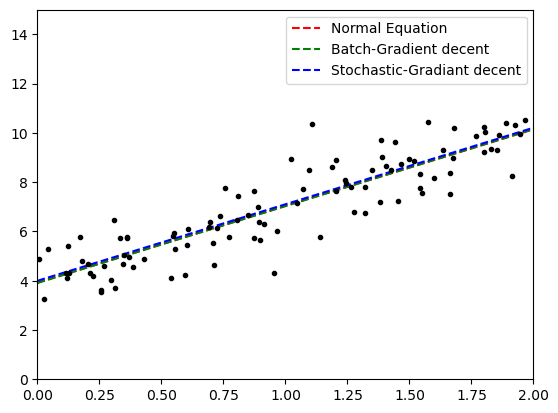

In [39]:
#own test
X = 2 * np.random.rand(100,1)
y = 4 +3 * X + np.random.randn(100,1)


#setting up model
model = MyLinReg()

#new values
X_new = np.array([[0],[2]])

#fitting and predicing using normal eq using normal eq
model.fit(X,y)
y_pred_normal_eq = model.predict(X_new)

#fitting using BGD and then predicting
theta0 = np.array([[2.0], [1.0]])
model.fitBGD(X,y,theta0)
y_pred_bgd = model.predict(X_new)

#fitting using SGF and then predicting
model.fitSGD(X,y,theta0,20)
y_pred_SGD = model.predict(X_new)


plt.plot(X_new,y_pred_normal_eq,"r-",label="Normal Equation")
plt.plot(X_new,y_pred_bgd,"g--",label="Batch-Gradient decent")
plt.plot(X_new,y_pred_SGD,"b--",label="Stochastic-Gradiant decent")
plt.plot(X,y,"k.")
plt.axis([0,2,0,15])
plt.legend()
plt.show()


In [4]:
%clear f

In [12]:
# Mini smoke test for your linear regressor: TestMyLinReg

import sys
import numpy

### SOME NIFTY HELPER FUNS ###

def isVector(y, expected_n=-1):
    assert isinstance(y, numpy.ndarray), f"expected type 'numpy.array' but got {type(y)}"
    assert y.ndim==1, f"expected y.ndim==1 but got {y.ndim}"
    assert expected_n<0 or expected_n==y.shape[0], f"expected vector of size {expected_n} but got size {y.shape}"
    return True

def isMatrix(X, expected_m=-1, expected_n=-1):
    assert isinstance(X, numpy.ndarray), f"expected type 'numpy.array' but got {type(X)}"
    assert X.ndim==2, f"expected X.ndim==2 but got {X.ndim}"
    assert expected_m<0 or expected_m==X.shape[0], f"expected matrix of size {expected_m}x{expected_n} but got size {X.shape}"
    assert expected_n<0 or expected_n==X.shape[1], f"expected vector of size {expected_m}x{expected_n} but got size {X.shape}"
    return True

def PrintMatrix(x, label="", precision=12, linewidth=60):
    hasFancy = False
    try:
        # NOTE: how does multiple import behave, any performance issues?
        from libitmal.utils import PrintMatrix as FancyPrintMatrix
        hasFancy = True
    except Exception as ex:
        Warn("could not import PrintMatrix from libitmal.utils, defaulting to simple function..")

    if hasFancy:
        FancyPrintMatrix(x, label=label, precision=precision, linewidth=linewidth)
    else:
        # default simple implementation
        print(f"{label}{' ' if len(label)>0 else ''}{x}")

def Col(color):
    hasFancy = False
    try:
        from libitmal.Utils.colors import Col as FancyCol
        hasFancy = True
    except Exception as ex:
        Warn("could not import Col from libitmal.Utils.colors, defaulting to simple function..")

    if hasFancy:
        return FancyCol(color)
    else:
        return ""

def ColEnd():
    hasFancy = False
    try:
        from libitmal.Utils.colors import ColEnd as FancyColEnd
        hasFancy = True
    except Exception as ex:
        Warn("could not import Col from libitmal.Utils.colors, defaulting to simple function..")

    if hasFancy:
        return FancyColEnd()
    else:
        return ""

def PrintOutput(msg, pre_msg, ex=None, color="", filestream=sys.stdout):

    def FormatTxt(txt, linewidth=60, prefix="", replacetabs=True):
        assert isinstance(txt, str)
        assert isinstance(linewidth, int) and linewidth > 0
        assert isinstance(prefix, str)

        if replacetabs:
            txt = txt.replace("\t","    ")

        r = ""
        n = 0
        m = 0
        for i in txt:
            m += 1
            if n >= linewidth:
                if not i.isspace() and m < len(txt) and not txt[m].isspace():
                    r += "\\" # add hypen
                r += "\n" + prefix
                n = 0

            if n == 0 and i.isspace():
                continue # skip leading space

            r += i
            n += 1

            if i == "\n":
                r += prefix
                n = 0

        return r

    col_beg = Col(color)
    col_end = ColEnd()

    prefix = "".ljust(len(pre_msg)) 
    msg = FormatTxt(msg, prefix=prefix)
    
    print(f"{col_beg}{pre_msg}{msg}{col_end}\n", file=filestream)

    if ex is not None:
        #msg += f"\n   EXCEPTION: {ex} ({type(ex)})"
        PrintOutput(str(ex), prefix + "EXCEPTION: ", None, "red", filestream)


def Warn(msg, ex=None):
    PrintOutput(msg, "WARN:  ", ex, "lyellow")


def Err(msg, ex=None):
    PrintOutput(msg, "ERROR: ", ex, "lred" )
    raise Exception(msg) if ex is None else ex


def Info(msg):
    PrintOutput(msg, "INFO:  ", None, "lpurple")


def SimpleAssertInRange(x, expected, eps):
    #assert isinstance(x, numpy.ndarray)
    #assert isinstance(expected, numpy.ndarray)
    #assert x.ndim==1 and expected.ndim==1
    #assert x.shape==expected.shape
    assert eps>0
    assert numpy.allclose(x, expected, eps) # should rtol or atol be set to eps?


def GenerateData():
    X = numpy.array([[8.34044009e-01],[1.44064899e+00],[2.28749635e-04],[6.04665145e-01]])
    y = numpy.array([5.97396028, 7.24897834, 4.86609388, 3.51245674])
    return X, y


def TestMyLinReg():
    X, y = GenerateData()

    try:
        # assume that your regressor class is named 'MyLinReg', please update/change
        regressor = MyLinReg()
    except Exception as ex:
        Err("your regressor has another name, than 'MyLinReg', please change the name in this smoke test", ex)

    try:
        regressor = MyLinReg(max_iter=200)
    except Exception as ex:
        Err("your regressor can not be constructed via the __init_ for parameter 'max_iter'", ex)
    try:
        regressor = MyLinReg(eta0=0.01)
    except Exception as ex:
        Err("your regressor can not be constructed via the __init_ for parameter 'eta0'", ex)
    try:
        regressor = MyLinReg(verbose=False)
    except Exception as ex:
        Warn("your regressor can not be constructed via the __init_ for parameter 'verbose'", ex)
    try:
        regressor = MyLinReg(tol=1e-3)
    except Exception as ex:
        Warn("your regressor can not be constructed via the __init_ for parameter 'tol'", ex)
    try:
        regressor = MyLinReg(n_iter_no_change=1e-3)
    except Exception as ex:
        Warn("your regressor can not be constructed via the __init_ for parameter 'n_iter_no_change'", ex)

    # create regressor with default hyperparameter values
    # to be used for training, prediction and score..
    try:
        regressor = MyLinReg()
    except Exception as ex:
        Err("your regressor can not be constructed via the __init_ with default parameters", ex)

    try:
        regressor.fit(X, y)
    except Exception as ex:
        Err("your regressor can not fit", ex)

    try:
        y_pred = regressor.predict(X)
        Info(f"y_pred = {y_pred}")
    except Exception as ex:
        Err("your regressor can not predict", ex)

    try:
        score  = regressor.score(X, y)
        Info(f"SCORE = {Col('lblue')}{score}{ColEnd()}")
    except Exception as ex:
        Err("your regressor fails in the score call", ex)


    try:
        w    = None # default
        bias = None # default
        try:
            w = regressor.coef_
            bias = regressor.intercept_
        except Exception as ex:
            w = None
            Warn("your regressor has no coef_/intercept_ atrributes, trying Weights() instead..", ex)
        try:
            if w is None:
                w = regressor.Weights() # maybe a Weigths function is avalible on you model?
                try:
                    assert w.ndim == 1,     "can only handle vector like w's for now"
                    assert w.shape[0] >= 2, "expected length of to be at least 2, that is one bias one coefficient"
                    bias = w[0]
                    w = w[1:]
                except Exception as ex:
                    w = None
                    Err("having a hard time concantenating our bias and coefficients, giving up!", ex)
        except Exception as ex:
            w = None
            Err("your regressor also has no Weights() function, giving up!", ex)
        Info(f"bias         = {bias}")
        Info(f"coefficients = {w}")
    except Exception as ex:
        Err("your regressor fails during extraction of bias and weights (but is a COULD)", ex)

    try:
        from libitmal.utils import PrintMatrix
    except Exception as ex:
        PrintMatrix = SimplePrintMatrix # fall-back
        Warn("could not import PrintMatrix from libitmal.utils, defaulting to simple function..")

    try:
        from libitmal.utils import AssertInRange
    except Exception as ex:
        AssertInRange = SimpleAssertInRange # fall-back
        Warn("could not import AssertInRange from libitmal.utils, defaulting to simple function..")

    try:
        if w is not None:
            if bias is not None:
                w = numpy.concatenate(([bias], w)) # re-concat bias an coefficients, may be incorrect for your implementation!
            
            # TEST VECTOR:
            w_expected = numpy.array([4.046879011698, 1.880121487278])
            
            PrintMatrix(w,          label="       w         =")
            PrintMatrix(w_expected, label="       w_expected=")
            print()
            
            eps = 1E-2 # somewhat big epsilon, allowing some slack..
            AssertInRange(w, w_expected, eps)
            Info("Well, good news, your w and the expected w-vector seem to be very close numerically, so the smoke-test has passed!")
            
            return regressor
        else:
            Warn("cannot test due to missing w information")
    except Exception as ex:
        Err("mini-smoketest on your regressor failed", ex)
    
    return None

Warn("This mini smoke-test may produce false-positives and/or\n false-negatives..")
TestMyLinReg()

print("OK")

WARN:  This mini smoke-test may produce false-positives and/or
       false-negatives..

INFO:  y_pred = [5.61498307 6.75547413 4.04730909 5.18372294]

INFO:  SCORE = 0.49500564295574767

INFO:  bias         = 4.046879011698291

INFO:  coefficients = [1.88012149]

       w         =[4.05 1.88]
       w_expected=[4.05 1.88]

INFO:  Well, good news, your w and the expected w-vector seem to be
       very close numerically, so the smoke-test has passed!

OK


# Lecture 7 - Learning Curves

## Qa) The generalization error

En detaljeret beskrivelse

## Qb Learning curves

Firstly. The linear regressor is updated with a loss history function. This is done by intializing an empty list in the fit interfaces of SGD and BGD, and then appendning the loss for each epoch/iteration. The list can be retrieved by calling model.LossHistory()

In [40]:
class MyLinReg(BaseEstimator,RegressorMixin):
    #inherits R2 score from RegressorMixin
    def __init__(self, eta0=0.05, tol=1e-3, max_iter = 100, n_iter_no_change=5, verbose=True):
        self.eta0 = eta0 #stepsize
        self.max_iter = max_iter
        self.tol = tol
        self.n_iter_no_change = n_iter_no_change

    def __str__(self):
        return "MyLinReg.__str__(): hi!"

    def fit(self, X, y):    
        #adding bias term
        n = len(y)
        X = np.c_[np.ones((n,1)), X] 

        #normal equation implementation
        self.theta = np.linalg.pinv(X) @ y #using the pseudoinverse so it works
        self.intercept_, self.coef_ = self.theta[0], self.theta[1:]

        #loss history
        self.loss_history = [] #resetting loss history
        self.loss_history.append(self.loss(self.theta,X,y)) #storing loss history (redundant feature in this case)
        return self

    def Weights(self):
        return self.theta
        
    def predict(self, X):
        #adding bias term
        n = X.shape[0] #is the same as len(y) but i dont have len(y) here.
        X = np.c_[np.ones((n,1)), X] 
        return X@self.theta

    def loss(self,theta,X,y):
        #based on MSE
        n = len(y)
        #calculation of the sum used in MSE. Vectorized.
        s = (X@theta-y).T@(X@theta-y)

        return (s/n).item() #vectorization gives problems and returns a (1,1) array. .item() converts this to a scalar.
    
    def fitBGD(self,X,y,theta0):
        self.loss_history = [] #resetting loss history

        n = len(y)
        X = np.c_[np.ones((n,1)), X] 
        theta = theta0 #intializing

        self.BGDiterations = 0 #for coutning no. iterations
        
        for it in range(self.max_iter): #running until max iterations.
            self.BGDiterations += 1 #counting no of iterations
            
            Nabla_theta = 2/n * X.T@(X@theta-y)
            theta = theta - self.eta0*Nabla_theta #this is with constant learning rate
            
            self.loss_history.append(self.loss(theta,X,y)) #storing loss history. In this case, its per iteration.
            
        self.theta = theta #storing final weights.
        
    def fitSGD(self,X,y,theta0,n_epochs):
        self.loss_history = [] #resetting loss history.  

        n = len(y)
        X = np.c_[np.ones((n,1)), X] #adding bias term
        theta = theta0 #initializing
        def learning_schedule(t):
            t0,t1 = 5,50 #standard værdierne fra bogen idk
            return t0 / (t+t1)
        for epoch in range(n_epochs):
            self.loss_history.append(self.loss(theta,X,y)) #storing loss history per epoch
            for i in range(n):
                ridx = np.random.randint(n) #choosing random index
                xi = X[ridx:ridx+1]
                yi = y[ridx:ridx+1]
                nabla_theta = 2*xi.T@(xi@theta-yi)
                eta = learning_schedule(epoch*n+i) #adaptive learning rate :)
                theta = theta - eta * nabla_theta

        self.theta=theta
        
    ##-------- ADDED LOSS HISTORY FUNCTION ----------##
    def LossHistory(self): 
        return self.loss_history
        
        

The loss vs epoch graph is created for the SGD. Additionally, a loss vs iterations for the BGD model.

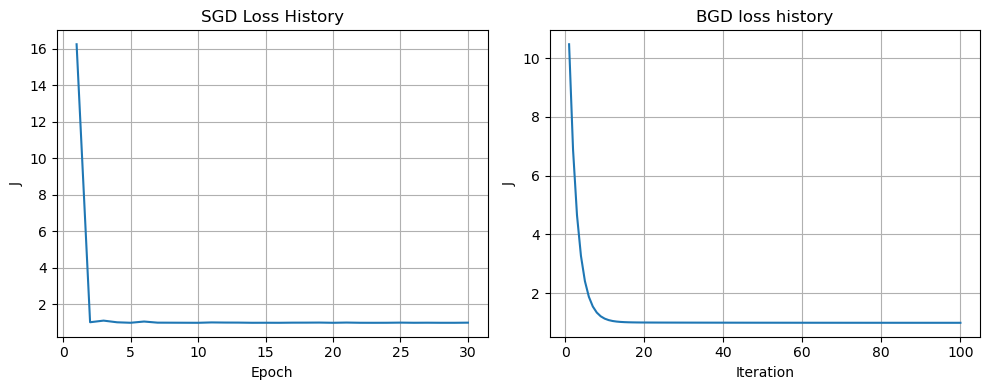

OK


In [14]:
#intansiating two models, both SGD and BGD
r = MyLinReg()
o = MyLinReg()
#generating some random data and fitting it
X = 2 * np.random.rand(100,1)
y = 4 +3 * X + np.random.randn(100,1) #creating some rather noisy data


#fitting using Stochastic Gradiant Descent 
theta0 = np.array([[2.0], [1.0]]) #initial values
n_epochs = 30 #number of epochs
r.fitSGD(X,y,theta0,n_epochs)

#fiting using BGD
o.fitBGD(X,y,theta0)

#extracting loss histories
h1 = r.LossHistory()
h2 = o.LossHistory()

# Plot of J vs. epoch for SGD and J vs iteration for BGD

q1 = np.arange(1,n_epochs+1) #plotting vs no of epochs. Creating a list with values [1,2,...,no_epochs] to plot against.
q2 = np.arange(1,o.BGDiterations+1) #same for no.iterations.

%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#SGD loss history plot
axes[0].plot(q1, h1)
axes[0].set_title("SGD Loss History")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("J")
axes[0].grid()
#BGD loss history plot
axes[1].plot(q2, h2)
axes[1].set_title("BGD loss history")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("J")
axes[1].grid()

plt.tight_layout()
plt.show()

print("OK")


## Qc Early Stopping

Early stopping is to be implemented. Early stopping is a method to regularize iterative learning algorithms such as the implemented BGD and SGD. The idea is to stop training as soon as the validuation error reaches a minimum. This is best explained by the use of the picture below.

<img src="https://itundervisning.ase.au.dk/SWMAL/L07-Generalisation/Figs/early_stopping.png" alt="WARNING: could not get image from server.">

As seen on the Loss vs Epoch graph, the loss function decreases and keeps decreasing on the training set as expected. As the epochs increase, the loss on the training set goes down aswell as the loss on the validation set. After some time, the loss on the validation set starts to increase, which is a clear indicator that the model has started to overfit on the training data. The idea of early stopping is to stop training once the validation error starts increasing too much. In the model above, this would be an actual true minimum, but in real cases one is not always that lucky. In machining learning, some minimum is better than no minimum, and with limitied time, that minimum might be able to perform to requirements. A possible solution to help make sure the model has reached the minimum, is to stop only after the valiation error has been above the minimum for some time, then roll back the model to that specific no. of epochs. In the implementation below, this is not implemented.

In [41]:
## Linear regressor is updated with early stopping functionality.
class MyLinReg(BaseEstimator,RegressorMixin):
    #inherits R2 score from RegressorMixin
    def __init__(self, eta0=0.05, tol=1e-3, max_iter = 100, n_iter_no_change=5, verbose=True):
        self.eta0 = eta0 #stepsize
        self.max_iter = max_iter
        self.tol = tol
        self.n_iter_no_change = n_iter_no_change

    def __str__(self):
        return "MyLinReg.__str__(): hi!"

    def fit(self, X, y):    
        #adding bias term
        n = len(y)
        X = np.c_[np.ones((n,1)), X] 

        #normal equation implementation
        self.theta = np.linalg.pinv(X) @ y #using the pseudoinverse so it works
        self.intercept_, self.coef_ = self.theta[0], self.theta[1:]

        #loss history
        self.loss_history = [] #resetting loss history
        self.loss_history.append(self.loss(self.theta,X,y)) #storing loss history (redundant feature in this case)
        return self

    def Weights(self):
        return self.theta
        
    def predict(self, X):
        #adding bias term
        n = X.shape[0] #is the same as len(y) but i dont have len(y) here.
        X = np.c_[np.ones((n,1)), X] 
        return X@self.theta

    def loss(self,theta,X,y):
        #based on MSE
        n = len(y)
        #calculation of the sum used in MSE. Vectorized.
        s = (X@theta-y).T@(X@theta-y)

        return (s/n).item() #vectorization gives problems and returns a (1,1) array. .item() converts this to a scalar.
    
    def fitBGD(self,X,y,theta0,X_val=None, y_val=None,early_stopping=True):
        self.loss_history = [] #resetting loss history
        self.loss_history_val = []
        best_val_loss = np.inf #initializing best loss as infinity, such that the first loss calculated is always better.

        #adding bias term
        n = len(y)
        X = np.c_[np.ones((n,1)), X] 
        theta = theta0 #intializing

        self.BGDiterations = 0 #for coutning no. iterations

        #adding bias term to validation set
        if X_val is not None:
            n_val = X_val.shape[0]
            X_val = np.c_[np.ones((n_val,1)),X_val]
        
        for it in range(self.max_iter): #running until max iterations.
            self.BGDiterations += 1 #counting no of iterations
            Nabla_theta = 2/n * X.T@(X@theta-y)
            theta = theta - self.eta0*Nabla_theta #this is with constant learning rate

            #loss history
            current_loss = self.loss(theta,X,y)
            self.loss_history.append(current_loss) #storing loss history. In this case, its per iteration.

            #calculation of validation history
            if X_val is not None and y_val is not None:
                current_val_loss = self.loss(theta,X_val,y_val) #calculating loss on validation set for current epoch
                self.loss_history_val.append(current_val_loss)

                #early stopping implementation
                if early_stopping: #only triggers if early stopping is true. (it is by default)
                    if best_val_loss - current_val_loss > self.tol:
                        best_val_loss = current_val_loss
                    else:
                        break

            
        self.theta = theta #storing final weights.
        
    def fitSGD(self,X,y,theta0,n_epochs,X_val=None, y_val=None,early_stopping=True):
        self.loss_history = [] #resetting loss history.
        self.loss_history_val = []
        self.SGDtotal_epochs = 0
        best_val_loss = np.inf #initializing best loss as infinity, such that the first loss calculated is always better.
        
        n = len(y)
        X = np.c_[np.ones((n,1)), X] #adding bias term
        theta = theta0 #initializing

        #adding bias term to validation set
        if X_val is not None:
            n_val = X_val.shape[0] 
            X_val = np.c_[np.ones((n_val,1)), X_val] 
        
        def learning_schedule(t):
            t0,t1 = 5,50 #standard værdierne fra bogen idk
            return t0 / (t+t1)
            
        for epoch in range(n_epochs):
            current_loss = self.loss(theta,X,y) #calculating current loss
            self.loss_history.append(current_loss) #storing loss history per epoch
            self.SGDtotal_epochs += 1 #adding count on total epochs
            
            #calculation of validation history
            if X_val is not None and y_val is not None:
                
                current_val_loss = self.loss(theta,X_val,y_val) #calculating loss on validation set for current epoch
                self.loss_history_val.append(current_val_loss)

                if early_stopping: #only triggers if early stopping is true. (it is by default)
                    if best_val_loss - current_val_loss > self.tol:
                        best_val_loss = current_val_loss
                    else:
                        break
            
            for i in range(n):
                ridx = np.random.randint(n) #choosing random index
                xi = X[ridx:ridx+1]
                yi = y[ridx:ridx+1]
                nabla_theta = 2*xi.T@(xi@theta-yi)
                eta = learning_schedule(epoch*n+i) #adaptive learning rate :)
                theta = theta - eta * nabla_theta

        self.theta=theta
        
    def LossHistory(self): 
        return self.loss_history
        
    def LossHistoryValidation(self):
        return self.loss_history_val
        

Now its time to fit and compare with the old model! Lets start by examplifying using the SGD model. A loss history on the validation set has been implemented in similar fashion to the one for the training set. This is used for plotting purposes and is called using model.LossHistoryValidation

Final validation loss with early stopping: 10.179088322693273, Final validation loss without early stopping: 8.988432141532636


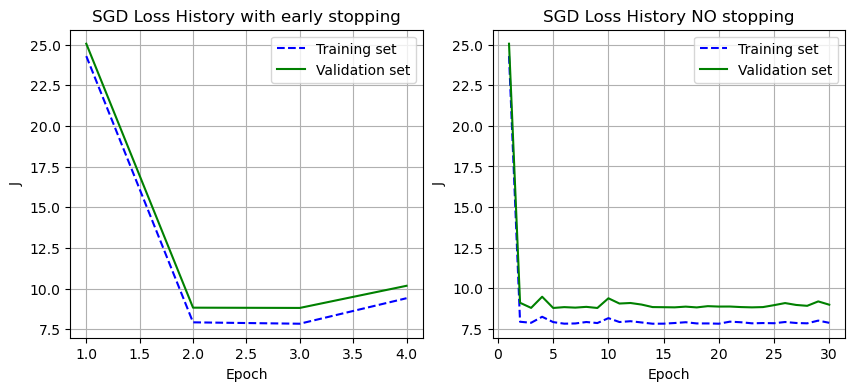

In [37]:
#intansiating two models, one with early stopping and one without it.
r1 = MyLinReg()
r2 = MyLinReg()

#generating some random data and fitting it
X = 2 * np.random.rand(100,1)
y = 4 + 3 * X + 3*np.random.randn(100,1) #creating some rather noisy data

#splitting data into train and test (shuffling aswell)
indices = np.arange(len(X))
np.random.shuffle(indices)
X_train, X_valid = X[indices[:80]], X[indices[80:]]
y_train, y_valid = y[indices[:80]], y[indices[80:]]


#fitting using Stochastic Gradiant Descent 
theta0 = np.array([[2.0], [1.0]]) #initial values
n_epochs = 30 #number of epochs

r1.fitSGD(X_train,y_train,theta0,n_epochs,X_valid,y_valid) 
r2.fitSGD(X_train,y_train,theta0,n_epochs,X_valid,y_valid,early_stopping=False)


#extracting loss histories and validation loss histories
h1 = r1.LossHistory()
vh1 = r1.LossHistoryValidation()

h2 = r2.LossHistory()
vh2 = r2.LossHistoryValidation()

# Plot of J vs. epoch for SGD and J vs iteration for BGD
q1 = np.arange(1,r1.SGDtotal_epochs+1) #plotting vs no of epochs. Creating a list with values [1,2,...,no_epochs] to plot against.
q2 = np.arange(1,r2.SGDtotal_epochs+1)
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#SGD loss history plot with early stopping
axes[0].plot(q1, h1,"b--",label="Training set")
axes[0].plot(q1, vh1,"g",label="Validation set")
axes[0].set_title("SGD Loss History with early stopping")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("J")
axes[0].grid()
axes[0].legend()

#SGD loss history plot withOUT early stopping
axes[1].plot(q2, h2,"b--",label="Training set")
axes[1].plot(q2, vh2,"g",label="Validation set")
axes[1].set_title("SGD Loss History NO stopping")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("J")
axes[1].grid()
axes[1].legend()
print(f"Final validation loss with early stopping: {vh1[-1]}, Final validation loss without early stopping: {vh2[-1]}")


As we can see, the number of epochs is reduced drastically! The resulting validation error is roughly the same, although actually a bit better with early stopping. Moving onto batch gradiant descent.

Final validation loss with early stopping: 8.865260680363296, Final validation loss without early stopping: 8.871666943938504


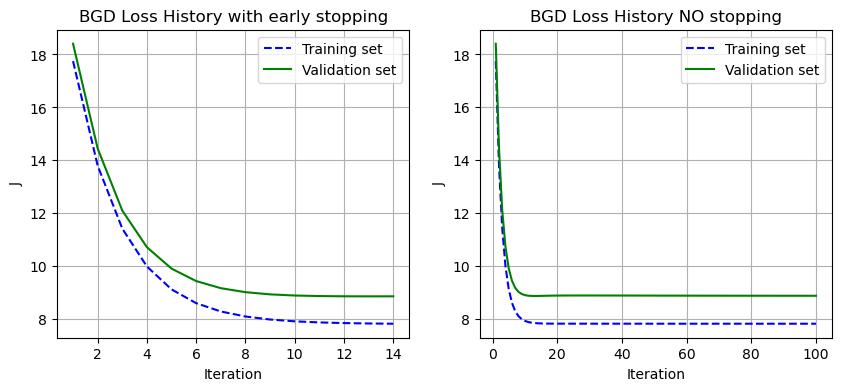

In [42]:
o1 = MyLinReg()
o2 = MyLinReg()

o1.fitBGD(X_train,y_train,theta0,X_valid,y_valid) #using same theta0 as in SGD
o2.fitBGD(X_train,y_train,theta0,X_valid,y_valid,early_stopping=False)

#extracting loss histories and validation loss histories
h1 = o1.LossHistory()
vh1 = o1.LossHistoryValidation()
h2 = o2.LossHistory()
vh2 = o2.LossHistoryValidation()

# Plot of J vs. no. of iterations for BGD
q1 = np.arange(1,o1.BGDiterations+1) 
q2 = np.arange(1,o2.BGDiterations+1)

%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#SGD loss history plot with early stopping
axes[0].plot(q1, h1,"b--",label="Training set")
axes[0].plot(q1, vh1,"g",label="Validation set")
axes[0].set_title("BGD Loss History with early stopping")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("J")
axes[0].grid()
axes[0].legend()

#SGD loss history plot withOUT early stopping
axes[1].plot(q2, h2,"b--",label="Training set")
axes[1].plot(q2, vh2,"g",label="Validation set")
axes[1].set_title("BGD Loss History NO stopping")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("J")
axes[1].grid()
axes[1].legend()

print(f"Final validation loss with early stopping: {vh1[-1]}, Final validation loss without early stopping: {vh2[-1]}")

Similar to what was seen in the SGD a considrabe amount of iterations are saved. In this run, the validation loss reaches a plateau, and starts decreasing so little that the difference in the validation loss between each iteration is so small, that early stopping is triggered.

# Lecture 8 - Regulisers

## Qa) The penalty factor

In [10]:
# Qa..first define some numeric helper functions for the test-vectors..

import numpy as np
from collections.abc import Iterable # fix of missing .abc

def isFloat(x):
    # is there a python single/double float??
    return isinstance(x, float) or isinstance(x, np.float32) or isinstance(x, np.float64)
    # NOT defined on Windows?:   or isinstance(x, np.float128)      

# Checks that a 'float' is 'sane' (original from libitmal)
def CheckFloat(x, checkrange=False, xmin=1E-200, xmax=1E200, verbose=0):
    if verbose>1:
        print(f"CheckFloat({x}, type={type(x)}")
    if isinstance(x, Iterable):
        for i in x:
            CheckFloat(i, checkrange=checkrange, xmin=xmin, xmax=xmax, verbose=verbose)
    else:
        #if (isinstance(x,int)):
        #    print("you gave me an integer, that was ignored")
        #    return
        assert isFloat(x), f"x={x} is not a float/float64/numpy.float32/64/128, but a {type(x)}"
        assert np.isnan(x)==False , "x is NAN"
        assert np.isinf(x)==False , "x is inf"
        assert np.isinf(-x)==False, "x is -inf"
        # NOTE: missing test for denormalized float
        if checkrange:
            z=fabs(x)
            assert z>=xmin, f"abs(x)={z} is smaller that expected min value={xmin}"
            assert z<=xmax, f"abs(x)={z} is larger that expected max value={xmax}"
        if verbose>0:
             print(f"CheckFloat({x}, type={x} => OK")

# Checks that two 'floats' are 'close' (original from libitmal)
def CheckInRange(x, expected, eps=1E-9, autoconverttofloat=True, verbose=0):
    assert eps>=0, "eps is less than zero"
    if autoconverttofloat and (not isFloat(x) or not isFloat(expected) or not isFloat(eps)):
        if verbose>1:
            print(f"notice: autoconverting x={x} to float..")
        return CheckInRange(1.0*x, 1.0*expected, 1.0*eps, False, verbose)
    CheckFloat(x)
    CheckFloat(expected)
    CheckFloat(eps)
    x0 = expected - eps
    x1 = expected + eps
    ok = x>=x0 and x<=x1
    absdiff = np.fabs(x-expected)
    if verbose > 0:
        print(f"CheckInRange(x={x}, expected={expected}, eps={eps}: x in [{x0}; {x1}] => {ok}")
    assert ok, f"x={x} is not within the range [{x0}; {x1}] for eps={eps}, got eps={absdiff}"

print("OK(setup..)")

OK(setup..)


Now that setup is done, it is time to implement a penalty function based on the L2 norm

In [13]:
# TODO: code
    
def Omega(w):
    return w[1:].T@w[1:] #removes first index and computes l2 norm
    
 
# weight vector format: [w_0 w_1 .. w_d], ie. elem. 0 is the 'bias'    
w_a = np.array([1., 2., -3.])  
w_b = np.array([1E10, -3E10])
w_c = np.array([0.1, 0.2, -0.3, 0])

p_a = Omega(w_a)
p_b = Omega(w_b)
p_c = Omega(w_c)

print(f"P(w0)={p_a}")
print(f"P(w1)={p_b}")
print(f"P(w2)={p_c}")

# TEST VECTORS
e0 = 2*2+(-3)*(-3)
e1 = 9e+20
e2 = 0.13

CheckInRange(p_a, e0)
CheckInRange(p_b, e1)
CheckInRange(p_c, e2)

print("OK")

P(w0)=13.0
P(w1)=9e+20
P(w2)=0.13
OK


As we can see, we get different magnitudes of penalties. As the penalty in this case uses the eucledian norm, the penalty is the magnitude of the vector squared. A vector having large weights will therefore recieve a larger penalty.

## Qb Explain the ridge plot

/home/jenz/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.744e+00, tolerance: 9.295e-04
  model = cd_fast.enet_coordinate_descent(
/home/jenz/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.774e+00, tolerance: 9.295e-04
  model = cd_fast.enet_coordinate_descent(


OK(plot)


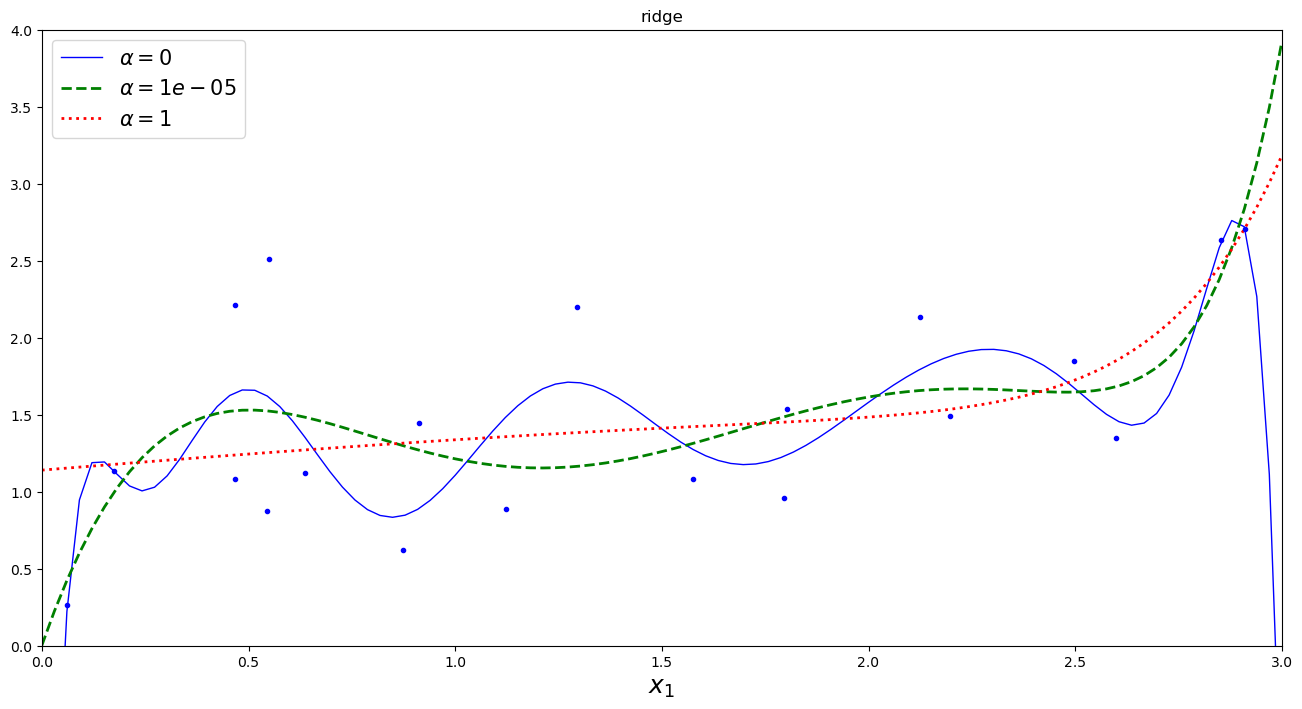

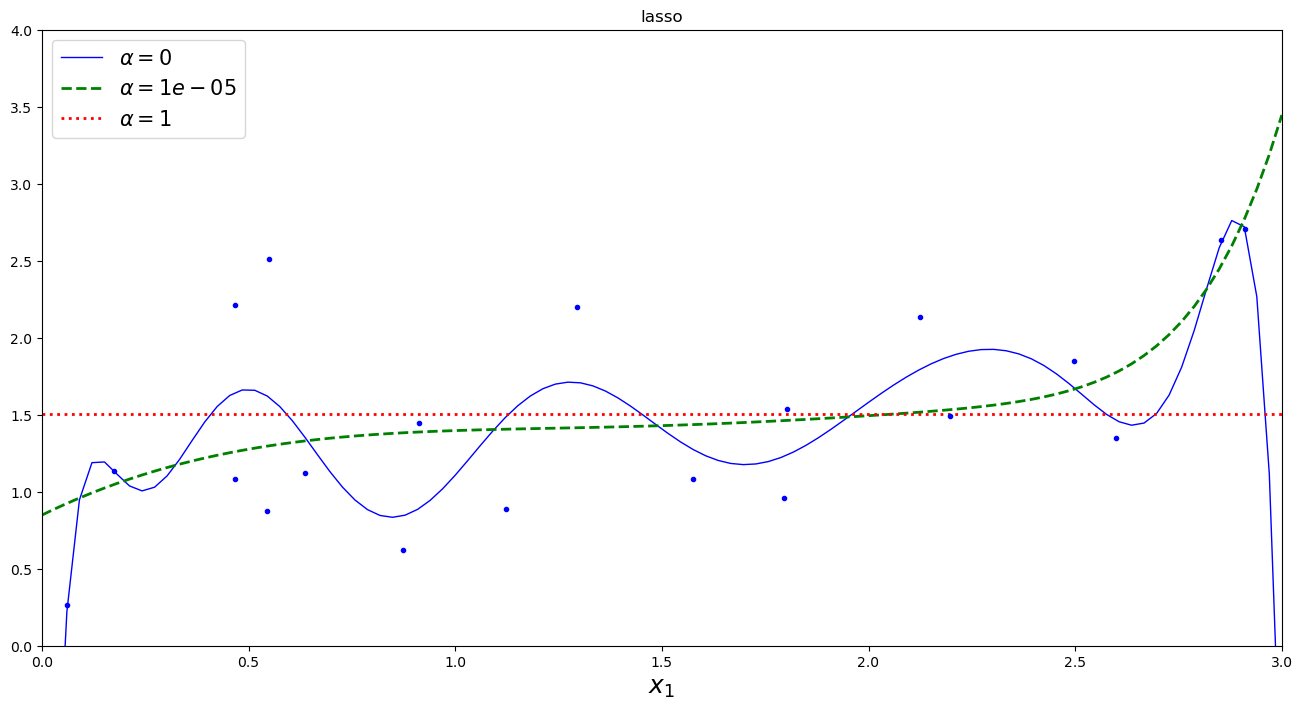

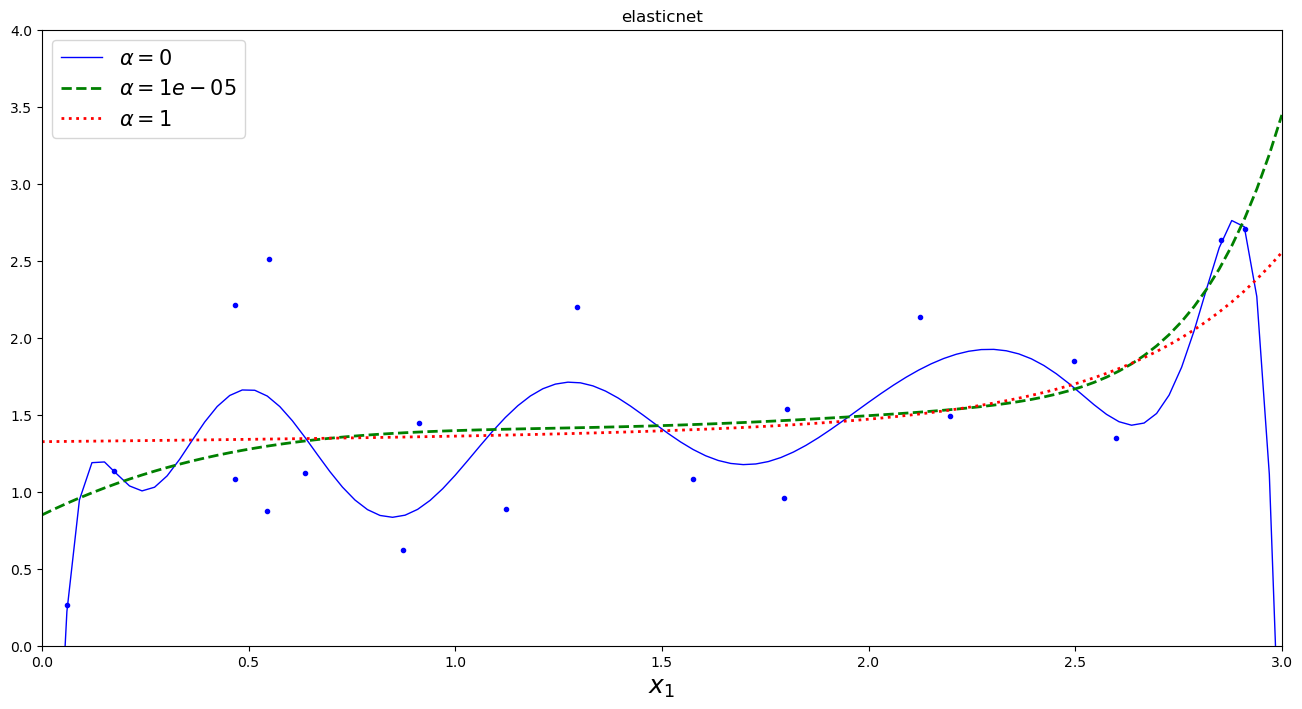

In [14]:
# TODO: Qb, just run the code..

%matplotlib inline

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, ElasticNet, Lasso

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

def FitAndPlotModel(name, model_class, X, X_new, y, **model_kargs):
    plt.figure(figsize=(16,8))
    
    alphas=(0, 10**-5, 1) 
    random_state=42
    
    for alpha, style in zip(alphas, ("b-", "g--", "r:")):
        #print(model_kargs)
        model = model_class(alpha, **model_kargs) if alpha > 0 else LinearRegression()
        model_pipe = Pipeline([
                ("poly_features", PolynomialFeatures(degree=12, include_bias=False)),
                ("std_scaler", StandardScaler()),
                ("regul_reg", model),
            ])
            
        model_pipe.fit(X, y)
        y_new_regul = model_pipe.predict(X_new)
        
        lw = 2 if alpha > 0 else 1
        plt.plot(X_new, y_new_regul, style, linewidth=lw, label=r"$\alpha = {}$".format(alpha))
    
    plt.plot(X, y, "b.", linewidth=3)
    plt.legend(loc="upper left", fontsize=15)
    plt.xlabel("$x_1$", fontsize=18)
    plt.title(name)
    plt.axis([0, 3, 0, 4])

def GenerateData():
    np.random.seed(42)
    m = 20
    X = 3 * np.random.rand(m, 1)
    y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
    X_new = np.linspace(0, 3, 100).reshape(100, 1)
    return X, X_new, y
    
X, X_new, y = GenerateData()

FitAndPlotModel('ridge',      Ridge,        X, X_new, y)
FitAndPlotModel('lasso',      Lasso,        X, X_new, y)
FitAndPlotModel('elasticnet', ElasticNet,   X, X_new, y, l1_ratio=0.1)

print("OK(plot)")

## Qc explain the ridge, lasso and ElasticNet Regularization Methods

Kasperh ar lavet, så gider ik

# Lecture 9 - Data Anlysis

## Qa) Beskrivelse af datasæt til O4 projekt

Se docs

## Qb) Datanalyse af eget dataset

det skal lige laves - tænker følg hans eksempel fra bogen?!

# Lecture 10 - Python-ML / pipelines

The data is loaded from the pickle file from L01

In [41]:
%matplotlib inline

import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def LoadDataFromL01():
    filename = "Data/itmal_l01_data.pkl"
    with open(f"{filename}", "rb") as f:
        (X, y) = pickle.load(f)
        return X, y

X, y = LoadDataFromL01()

print(f"X.shape={X.shape},  y.shape={y.shape}")

assert X.shape[0] == y.shape[0]
assert X.ndim == 2
assert y.ndim == 1  # did a y.ravel() before saving to picke file
assert X.shape[0] == 29

# re-create plot data (not stored in the Pickel file)
m = np.linspace(0, 60000, 1000)
M = np.empty([m.shape[0], 1])
M[:, 0] = m

print("OK")

X.shape=(29, 1),  y.shape=(29,)
OK


Revisiting the awful implementation of the MLP regressor without any scaling

The MLP may mis-fit the data, seen in the, sometimes, bad R^2 score..

lin.reg.score(X, y)=0.73
    MLP.score(X, y)=-219764.70

OK


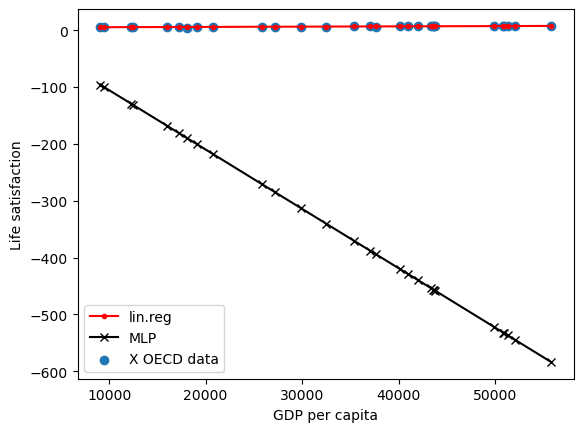

In [42]:
# Setup the MLP and lin. regression again..

def isNumpyData(t: np.ndarray, expected_ndim: int):
    assert isinstance(expected_ndim, int), f"input parameter 'expected_ndim' is not an integer but a '{type(expected_ndim)}'"
    assert expected_ndim>=0, f"expected input parameter 'expected_ndim' to be >=0, got {expected_ndim}"
    if t is None:
        print("input parameter 't' is None", file=sys.stderr)
        return False
    if not isinstance(t, np.ndarray):
        print("excepted numpy.ndarray got type '{type(t)}'", file=sys.stderr)
        return False
    if not t.ndim==expected_ndim:
        print("expected ndim={expected_ndim} but found {t.ndim}", file=sys.stderr)
        return False
    return True

def PlotModels(model1, model2, X: np.ndarray, y: np.ndarray, name_model1: str, name_model2: str):
    
    # NOTE: local function is such a nifty feature of Python!
    def CalcPredAndScore(model, X: np.ndarray, y: np.ndarray,):
        assert isNumpyData(X, 2) and isNumpyData(y, 1) and X.shape[0]==y.shape[0]
        y_pred_model = model.predict(X)
        score_model = r2_score(y, y_pred_model) # call r2
        return y_pred_model, score_model    

    assert isinstance(name_model1, str) and isinstance(name_model2, str)

    y_pred_model1, score_model1 = CalcPredAndScore(model1, X, y)
    y_pred_model2, score_model2 = CalcPredAndScore(model2, X, y)

    plt.plot(X, y_pred_model1, "r.-")
    plt.plot(X, y_pred_model2, "kx-")
    plt.scatter(X, y)
    plt.xlabel("GDP per capita")
    plt.ylabel("Life satisfaction")
    plt.legend([name_model1, name_model2, "X OECD data"])

    l = max(len(name_model1), len(name_model2))
    
    print(f"{(name_model1).rjust(l)}.score(X, y)={score_model1:0.2f}")
    print(f"{(name_model2).rjust(l)}.score(X, y)={score_model2:0.2f}")

# lets make a linear and MLP regressor and redo the plots
mlp = MLPRegressor(hidden_layer_sizes=(10, ),
                   solver='adam',
                   activation='relu',
                   tol=1E-5,
                   max_iter=100000,
                   verbose=False)
linreg = LinearRegression()

mlp.fit(X, y)
linreg.fit(X, y)

print("The MLP may mis-fit the data, seen in the, sometimes, bad R^2 score..\n")
PlotModels(linreg, mlp, X, y, "lin.reg", "MLP")
print("\nOK")

## Qa) Create a Min/max scaler for the MLP

A min/max scaler is to be implemented and the data is to be refitted. This will be done without a pipeline. The min max scaler is on the form
$$
\mathbf{X}_{scaled} = \frac{\mathbf{X}-\mathbf{X}_{min}}{\mathbf{X}_{max}-\mathbf{X}_{min}}
$$

In [19]:
def MinMaxScaler(X):
    X_min = np.min(X)
    X_max = np.max(X)
    return (X-X_min)/(X_max-X_min)



Now the data is scaled and refit

In [37]:
#scaling data
X_scaled = MinMaxScaler(X)


#creating model
mlp_scaled = MLPRegressor(hidden_layer_sizes=(10, ),
                   solver='adam',
                   activation='relu',
                   tol=1E-5,
                   max_iter=100000,
                   verbose=False)
#fitting
mlp_scaled.fit(X_scaled,y)
#predicting
y_pred_mlp_scaled = mlp_scaled.predict(X_scaled)


Now that a new MLP has been introduced, lets plot them to see if it peforms any better.

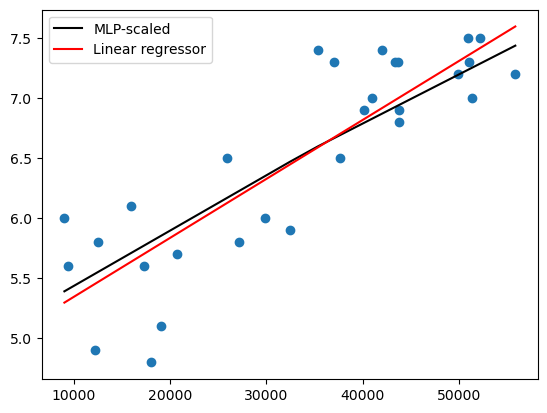

linreg R2 score: 0.73
Scaled MLP R2 score: 0.73


In [72]:
#prediction of linear regressor
y_pred_linreg = linreg.predict(X)

#plotting
plt.plot(X,y_pred_mlp_scaled,"k-",label="MLP-scaled")
plt.plot(X,y_pred_linreg,"r-",label="Linear regressor")
plt.scatter(X, y)
plt.legend()
plt.show()

print(f"linreg R2 score: {linreg.score(X,y):0.2f}")
print(f"Scaled MLP R2 score: {mlp_scaled.score(X_scaled,y):0.2f}")

It is apparent, that with prescaling, the MLP performas a lot better.